# OVERVIEW

This notebook serves as analysis of the attached src .py files, and an example of how to use them.

This notebook is split into three parts, the first part of which we try to fit a given model type to technical indicators and see what limitations we encounter. In the second part we study a cross-sectional excess return formulation and its applications, and what signals we can find in predicting market direction. In part 3, we start an ongoing test surrounding the use of the P-E ratio and RoE as potential signals for performance.

## *IMPORTS*

Script created in trading_bot project when encountering import issues due to notebook files and working in a different directory. same script added across every project. Also changed the names of plotting files to match the project name, as python automatically was chosing the first option when called. 

In [1]:

import sys
from pathlib import Path
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else Path.cwd().resolve()
    )
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "trading_bot",
    )
    _REPO_ROOT = next(
        (
            directory
            for directory in (_HERE, *_HERE.parents)
            if all((directory / project).is_dir() for project in _PROJECTS)
        ),
        None,
    )
    if _REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate the trading_portfolio repository root."
        )
    _SRC_PATHS = [
        str((_REPO_ROOT / project / "src").resolve())
        for project in _PROJECTS
    ]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True


In [2]:
#importing all packages/functions necessary
import numpy as np
import pandas as pd

from data_loader import fetch_price_data, get_sp500_tickers

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import multipletests


from features import build_features, build_multi_ticker_dataset, build_fundamental_features, start_forward_tracking, forward_evaluation_tracking
from labels import simple_labels, triple_barrier_labels, excess_return_target
from walk_forward import walk_forward_evaluate, walk_forward_evaluate_pooled, evaluate_oos_top_frac, evaluate_oos_score, walk_forward_ranked_portfolio, momentum_baseline_single, momentum_baseline_sweep, walk_forward_momentum_rule, hac_test
from plotting_ml_trading_signals import plot_oos_top_frac, plot_momentum_sweep, plot_forward_test_setup

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## PART 1

Begin by creating a dataframe containing many technical indicators of future direction as seen in the technical_analysis project.

In [3]:
ticker = "AAPL"
df = fetch_price_data(ticker, period="10y")
spy = fetch_price_data("SPY", period="10y")

features = build_features(df, spy_df=spy)

We create labels to indicate when to buy/sell. A simple label is simple (hence the name), if the forward return is above our threshold, then buy. A triple barrier label is where we have a profit_multipler, stop_multiplier and we label the trade to which barrier it hits first (assuming it hits either). Multipliers chosen at a 2:1 profit-stop ratio so that we can be incorrect half of the time and still profit. Both barriers scale with current volatility

In [4]:
labels_simple, fwd_ret = simple_labels(df, horizon=5, threshold=0.0)
print("Simple labels (5-day forward return > 0):")
print(f"  Class balance: {labels_simple.value_counts().to_dict()}")
print(f"  Positive rate: {labels_simple.mean():.4f}")

labels_tb, hold_days, tb_return = triple_barrier_labels(df, horizon=10)
print("\nTriple barrier (10-day horizon, 2:1 reward/risk):")
print(f"  Class balance: {labels_tb.value_counts().to_dict()}")
print(f"  Positive rate: {labels_tb.mean():.4f}")
print(f"  Avg holding period: {hold_days.mean():.2f} days")
print(f"  Avg return when label=1: {tb_return[labels_tb==1].mean()*100:.2f}%")
print(f"  Avg return when label=0: {tb_return[labels_tb==0].mean()*100:.2f}%")

Simple labels (5-day forward return > 0):
  Class balance: {1.0: 1468, 0.0: 1039}
  Positive rate: 0.5856

Triple barrier (10-day horizon, 2:1 reward/risk):
  Class balance: {0.0: 1419, 1.0: 1062}
  Positive rate: 0.4281
  Avg holding period: 3.47 days
  Avg return when label=1: 3.21%
  Avg return when label=0: -1.75%


It is key to note the change here. In earlier versions of this project, we would rani

In [5]:
features_clean = features.dropna()
labels_clean = labels_tb.reindex(features_clean.index)
fwd_ret_clean = tb_return.reindex(features_clean.index)

fold_results, oof_pred, oof_proba = walk_forward_evaluate(
    lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1,),
    features_clean, labels_clean, fwd_ret_clean, train_size=500, test_size=63, embargo=10,)

print(fold_results.to_string())

print(f"\nMean ROC-AUC: {fold_results['roc_auc'].mean():.4f}")
print(f"Mean accuracy: {fold_results['accuracy'].mean():.4f}")
print(f"Mean coverage: {fold_results['coverage'].mean():.2%}")

print("Mean selected-long return: "f"{fold_results['long_signal_return'].mean() * 100:.3f}%")
print("Mean long-only return: " f"{fold_results['long_only_return'].mean() * 100:.3f}%")
print("Mean benchmark return: " f"{fold_results['benchmark_return'].mean() * 100:.3f}%")
print("Mean conditional selection lift: " f"{fold_results['conditional_selection_lift'].mean() * 100:.3f}%")
print("Mean long-only excess: " f"{fold_results['long_only_excess'].mean() * 100:.3f}%")

single_oos = pd.concat([oof_pred.rename('prediction'), fwd_ret_clean.rename('fwd_return'),],axis=1,).dropna()

single_oos['long_only_return'] = np.where(single_oos['prediction'] == 1, single_oos['fwd_return'], 0.0,)

single_oos['benchmark_return'] = single_oos['fwd_return']

single_oos['excess_return'] = single_oos['long_only_return']- single_oos['benchmark_return']

t, p = hac_test(single_oos['excess_return'], horizon=10)

print(f"Long-only excess vs benchmark (HAC): " f"t={t:.3f}, p={p:.4f}")

    fold train_start test_start   test_end  n_train  n_test  accuracy   roc_auc  n_long  coverage  long_signal_return  long_only_return  benchmark_return  conditional_selection_lift  long_only_excess
0      0  2017-06-13 2019-06-24 2019-09-20      500      63  0.396825  0.431624       9  0.142857            0.012204          0.001743          0.015461                   -0.003257         -0.013718
1      1  2017-09-12 2019-09-23 2019-12-19      500      63  0.380952  0.417735       0  0.000000                 NaN          0.000000          0.010388                         NaN         -0.010388
2      2  2017-12-11 2019-12-20 2020-03-23      500      63  0.412698  0.497783      45  0.714286           -0.013006         -0.009290         -0.009537                   -0.003469          0.000247
3      3  2018-03-14 2020-03-24 2020-06-22      500      63  0.634921  0.657596      49  0.777778            0.031953          0.024853          0.027584                    0.004369         -0.002732


We see the results are middling, as we buy/sell at times which have no rationale. We see the strategy return has a general correlation with the ROC-AUC, but we test to see whether this is statistically significant, and whether this holds over the whole of the market and not one cherry picked ticker. Start by adding the features to a pooled feature of tickers

In [6]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM", "WMT", "PG", "HD", "DIS", "NFLX", "AMD", "INTC", "CSCO", "ADBE", "CRM"]

pooled = build_multi_ticker_dataset(tickers, period="10y", horizon=10, ranking_horizon=21)

print(f"Tickers included: {pooled['ticker'].nunique()}")
print(f"Date range: {pooled.index.min()} to {pooled.index.max()}")

Successfully loaded: 20 / 20 tickers
Tickers included: 20
Date range: 2016-08-26 00:00:00 to 2026-08-25 00:00:00


Now run the same test on this list of tickers

In [7]:
future_cols = {
    'label',
    'fwd_return',
    'ranking_return',
    'excess_return',
    'mom_return_1d',
    'mom_entry_date',
    'mom_exit_date',
    'ticker',
}

feature_cols = [c for c in pooled.columns if c not in future_cols]

pooled_folds, pooled_oos = walk_forward_evaluate_pooled(lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42,n_jobs=-1,), 
        pooled, feature_cols, train_size=250, test_size=63, embargo=10)

pooled_daily = evaluate_oos_top_frac(pooled_oos, top_frac=0.2, min_universe=5,)

display(pooled_folds)

classification_metrics = pooled_folds[[
        'roc_auc',
        'average_precision',
        'positive_rate',
        'brier_score',
    ]].mean()

selection_metrics = pooled_daily[[
        'top_label_rate',
        'universe_label_rate',
        'label_lift',
        'top_return',
        'universe_return',
        'excess_return',
    ]].mean() * 100

print("\nMean classification metrics:")
print(classification_metrics.round(4).to_string())

print("\nMean daily selection results (%):")
print(selection_metrics.round(4).to_string())

t_value, p_value = hac_test(pooled_daily['excess_return'], horizon=10,)

print("\nTop 20% excess vs universe (HAC): " f"t={t_value:.3f}, p={p_value:.4f}")

,fold,train_start,train_end,test_start,test_end,n_train,n_test,positive_rate,mean_probability,max_probability,accuracy,roc_auc,average_precision,brier_score
0,0,2017-06-13,2018-06-08,2018-06-25,2018-09-21,5000,1260,0.417460,0.414693,0.569091,0.551587,0.501596,0.398616,0.246918
1,1,2017-09-12,2018-09-07,2018-09-24,2018-12-21,5000,1260,0.264286,0.424716,0.561809,0.719841,0.570172,0.312159,0.218336
2,2,2017-12-11,2018-12-07,2018-12-24,2019-03-26,5000,1260,0.487302,0.383336,0.578018,0.515873,0.472015,0.478044,0.268914
3,3,2018-03-14,2019-03-12,2019-03-27,2019-06-25,5000,1260,0.380159,0.378713,0.565912,0.613492,0.503671,0.381490,0.237543
4,4,2018-06-13,2019-06-11,2019-06-26,2019-09-24,5000,1260,0.341270,0.379295,0.555325,0.658730,0.521437,0.357451,0.226248
5,5,2018-09-12,2019-09-10,2019-09-25,2019-12-23,5000,1260,0.463492,0.366706,0.479723,0.536508,0.463765,0.437682,0.266280
6,6,2018-12-12,2019-12-09,2019-12-24,2020-03-25,5000,1260,0.363492,0.410051,0.679186,0.621429,0.518221,0.382764,0.237477
7,7,2019-03-15,2020-03-11,2020-03-26,2020-06-24,5000,1260,0.476190,0.399547,0.534961,0.523810,0.493167,0.477278,0.257301
8,8,2019-06-14,2020-06-10,2020-06-25,2020-09-23,5000,1260,0.440476,0.418833,0.646871,0.561111,0.553664,0.487250,0.244676
9,9,2019-09-13,2020-09-09,2020-09-24,2020-12-22,5000,1260,0.425397,0.429544,0.556662,0.568254,0.496423,0.430854,0.247579



Mean classification metrics:
roc_auc              0.5013
average_precision    0.3853
positive_rate        0.3811
brier_score          0.2391

Mean daily selection results (%):
top_label_rate         37.4380
universe_label_rate    38.1101
label_lift             -0.6721
top_return              0.2888
universe_return         0.2534
excess_return           0.0353

Top 20% excess vs universe (HAC): t=0.527, p=0.5982


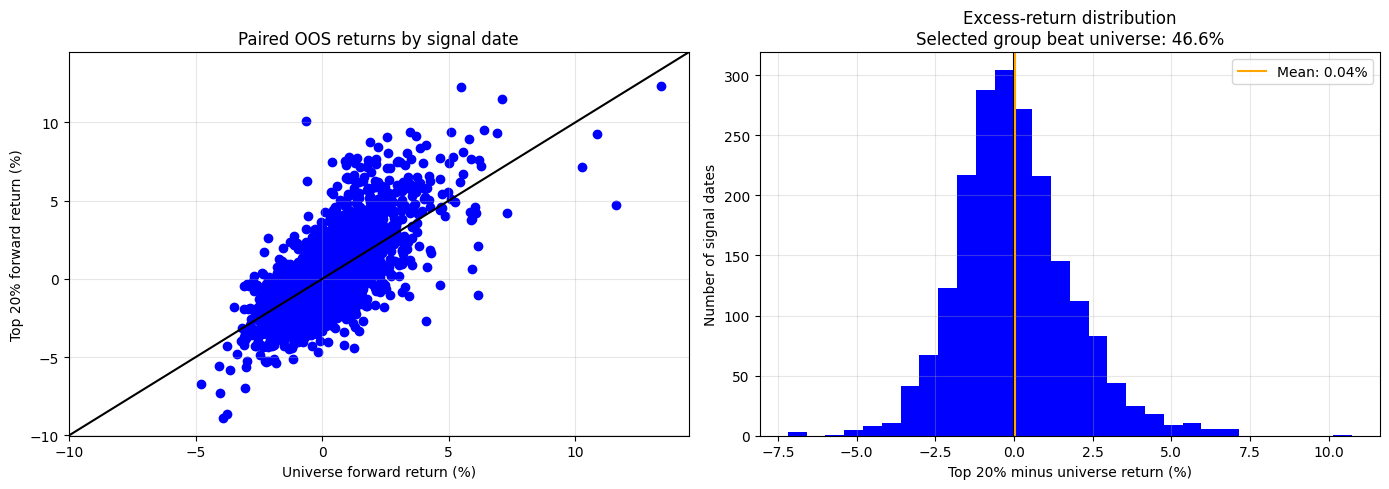

In [8]:
_ = plot_oos_top_frac(pooled_daily)

In [9]:
bucket_daily, bucket_summary = evaluate_oos_score(pooled_oos, n_buckets=5, min_universe=5,)

bucket_table = bucket_summary.copy()

bucket_table[['mean_probability', 'label_rate', 'mean_return']] *= 100

bucket_table = bucket_table.rename(columns={
    'mean_probability': 'mean_probability_%',
    'label_rate': 'label_rate_%',
    'mean_return': 'mean_return_%',
    })

display(bucket_table.round(4))

bucket_returns = bucket_daily.pivot(index='date', columns='bucket', values='mean_return').dropna()

top_minus_bottom = (bucket_returns[5] - bucket_returns[1])

t_value, p_value = hac_test(top_minus_bottom, horizon=10)

print("\nExploratory highest-minus-lowest bucket: " f"mean={top_minus_bottom.mean() * 100:.4f}%, " f"t={t_value:.3f}, p={p_value:.4f}")

,bucket,n_dates,mean_stocks,mean_probability_%,label_rate_%,mean_return_%
0,1,2016,4.0,32.4438,38.1324,0.2334
1,2,2016,4.0,35.7068,38.3061,0.2294
2,3,2016,4.0,37.5721,38.9509,0.2806
3,4,2016,4.0,39.5813,37.7232,0.2350
4,5,2016,4.0,43.7716,37.4380,0.2888



Exploratory highest-minus-lowest bucket: mean=0.0554%, t=0.528, p=0.5976


## PART 2

We use the cross-return excess return formulation found in "Machine Learning in Finance, From Theory to Practice", authored by "Matthew F. Dixon, Igor Halperin, Paul Bilokon", alongside a discussion around the 'momentum' signal. Start with the book's formulation. It is stated that a signal can be predictive of its own future and correlate with returns, but still not be a profitable strategy due to transaction costs and trade construction. Part of the issue in part 1 was portfolio selection, we chose a random selection of tickers with equal weighting. It was seen in the portfolio optimisation project that this isn't correct, although again that was also a random selection of tickers. The following formulation is followed:


$$
G_t =
\begin{cases}
1 & \text{if } \dfrac{1}{N}\sum_{i} r^i_{t+h,t} - \tilde{r}_{t+h,t} \geq \epsilon \\[2pt]
0 & \text{otherwise}
\end{cases}
$$
where:

$G_t$: label at time t, 1 being portfolio "beat the benchmark", 0 being did not.

$N$: number of tickers in portfolio/universe

$r^i_{t+h,t}$: returns of ticker i between $t + h, t$  ($h>0$)

$\tilde{r}_{t+h,t}$: returns of the benchmark over the same time period

$\epsilon$: small positive constant. If chosen too big, problem turns into an outlier detection problem. Returns within $\epsilon$ of the market mean can be treated as noise


Explicitly, this formula is not used, but is for inspiration. Below the stocks are ordered by excess returns continuously, from which a top percentile are selected

In [10]:
pooled_v2 = excess_return_target(pooled)

In [11]:
ranked = walk_forward_ranked_portfolio(lambda: RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), 
                                       pooled_v2, feature_cols, train_size=250, test_size=63, embargo=21, top_frac=0.2) #top_frac = 0.2 means top 20% of stocks are selected.

print(f"Total test days: {len(ranked)}")
print(f"Mean top-selected return:  {ranked['top_return'].mean()*100:.4f}%")
print(f"Mean bottom-avoided return: {ranked['bottom_return'].mean()*100:.4f}%")
print(f"Mean universe return:      {ranked['universe_return'].mean()*100:.4f}%")


top_vs_universe = ranked['top_return'] - ranked['universe_return']
top_vs_bottom = ranked['top_return'] - ranked['bottom_return']

t, p = hac_test(top_vs_universe, horizon=21)

t2, p2 = hac_test(top_vs_bottom, horizon=21)

print(f"\nTop vs universe: t={t:.3f}, p={p:.4f}")
print(f"Top vs bottom (paired): t={t2:.3f}, p={p2:.4f}")

Total test days: 2016
Mean top-selected return:  2.4426%
Mean bottom-avoided return: 1.8022%
Mean universe return:      1.8896%

Top vs universe: t=1.570, p=0.1167
Top vs bottom (paired): t=1.117, p=0.2642


There is still no significance when we walk forward with the same machine relative to both the universe return and relative to the bottom avoided return. As another trick to find a signal, we rank the stocks by momentum, the past k days of relative returns, whilst still holding the top 20%

In an attempt to get any form of significance, we rank stocks by momentum. This measures the last k days of relative returns (ranked at close, with returns being calculated from open on the following trading day, onwards), whilst retaining the top x%. Below have k=21, x=20

In [12]:
mom, t, p = momentum_baseline_single(pooled_v2, lookback_col='return_21d', top_frac=0.2, verbose=True)

Momentum top: 2.9045%  bottom: 2.0132%  universe: 2.0429%
Top vs bottom (HAC adjusted): t=1.692, p=0.0908


See insignificance here, but we continue looking in this direction as we are fairly close to a significance level. Notice the need for HAC-testing, due to overlapping periods during testing. Choosing the optimal values will require out of sample testing, as we see later.

In [13]:
sweep = momentum_baseline_sweep(pooled_v2)
print(sweep.to_string())

print("\nSignificant (p<0.05) top-vs-bottom results:")
print(sweep[sweep['p_top_vs_bottom'] < 0.05].to_string())

print("\nSignificant (p<0.05) top-vs-universe results:")
print(sweep[sweep['p_top_vs_universe'] < 0.05].to_string())

      lookback  top_frac  n_days  top_return  bottom_return  universe_return  top_minus_bottom  top_minus_universe  t_top_vs_bottom  p_top_vs_bottom_raw  t_top_vs_universe  p_top_vs_universe_raw  p_top_vs_bottom  p_top_vs_universe
0    return_5d       0.1    2486      2.8861         2.2876           2.0443            0.5986              0.8418           1.2083               0.2270             2.2371                 0.0254           1.0000             0.2029
1    return_5d       0.2    2486      2.5252         2.0794           2.0443            0.4458              0.4809           1.2040               0.2287             1.9482                 0.0515           1.0000             0.3541
2    return_5d       0.3    2486      2.3142         2.0603           2.0443            0.2539              0.2699           0.8748               0.3818             1.5457                 0.1223           1.0000             0.4892
3    return_5d       0.5    2486      2.0904         1.9982           2.0443

The sweep varies the selected fraction over [0.1, 0.2, 0.3, 0.5] and the momentum lookback over [5d, 10d, 21d, 63d]. Top figure shows (Holm-adjusted) p-values for top chosen tickers vs bottom chosen tickers, and bottom figure shows top-chosen vs universe average.

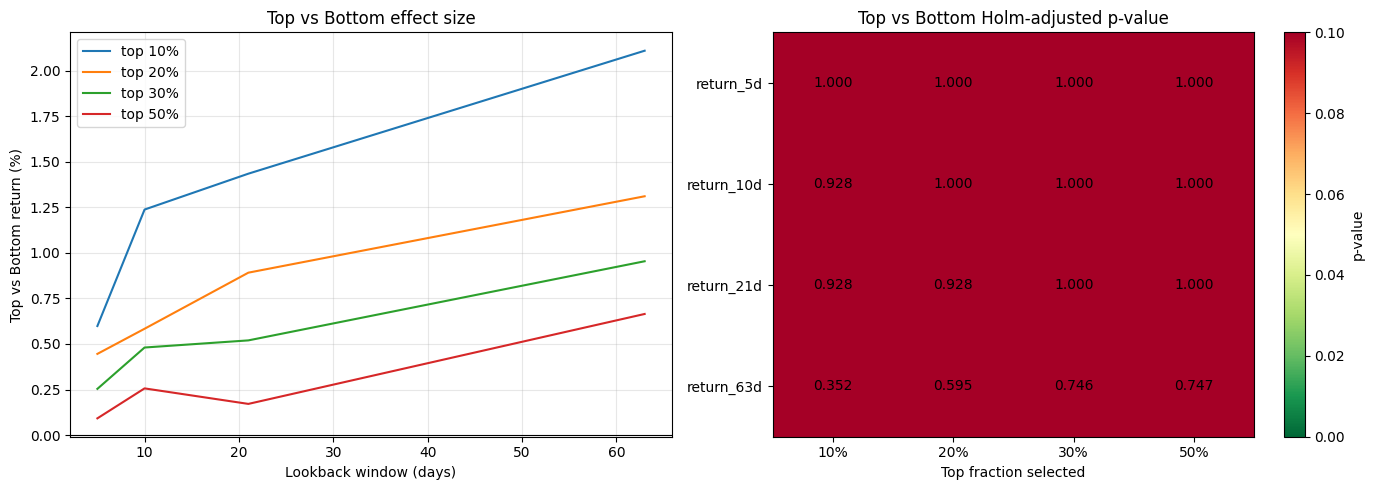

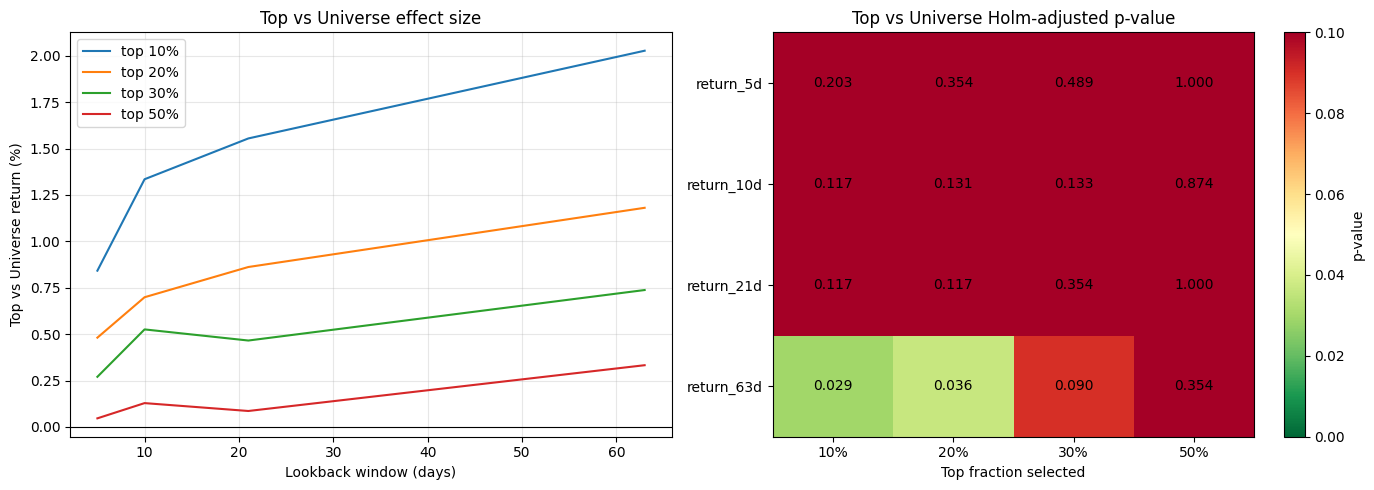

In [14]:
_ = plot_momentum_sweep(sweep)

See that the only significance at all is top-chosen vs universe average, while holding top 10%, 20% of the universe judging over 63d momentum, and all other observations are insignificant. This is the contrary to our previous result, where we thought we had significance in lots of places between top vs bottom selections over a variety of momentum days. This is due to HAC/Holm adjusting statistical measuring, and different implementation. Returns are now calculated differently, stocks are chosen by momentum ranking at close, and then the 'testing' of the performance starts at open the following trading day for the next horizon days, which is what ranking_return measures. 

Now take a walk-forward approach, where we test on each of the cases from the sweep. In each fold, each configuration is tested strictly on the test period, the configuration with the highest t-statistic is chosen (mean excess is there as a tiebreaker), before that configuration is fixed on the test data (after the embargo to stop leakage). The stocks and their weights are reranked daily, but the selection is fixed throughout the test period. Out of sample performances are the results on the test data after the basket of tickers is fixed.

In [ ]:
mom_wf_folds, mom_wf_daily = walk_forward_momentum_rule(pooled_v2, train_size=504, test_size=63, horizon=21, embargo=21, expanding=True)
print(mom_wf_folds.to_string(index=False))

print("\nRules selected across folds:")
print(mom_wf_folds.groupby(['lookback', 'top_frac']).size().rename('n_folds').to_string())

print(f"\nMean out-of-sample top return:      {mom_wf_daily['top_return'].mean()*100:.4f}%")
print(f"Mean out-of-sample universe return: {mom_wf_daily['universe_return'].mean()*100:.4f}%")
print(f"Mean out-of-sample excess:          {mom_wf_daily['excess'].mean()*100:.4f}%")

t, p = hac_test(mom_wf_daily['excess'], horizon=21)
print(f"Out-of-sample excess vs 0 (HAC): t={t:.3f}, p={p:.4f}")
print(f"Fraction of test days where top beat universe: {(mom_wf_daily['excess'] > 0).mean():.2%}")
print(f"Fraction of folds where top beat universe: {(mom_wf_folds['excess'] > 0).mean():.2%}")

 fold train_start  train_end test_start   test_end   lookback  top_frac  train_mean_excess  train_t_hac  train_p_raw  n_test_days  top_return  universe_return    excess
    0  2016-11-25 2018-11-26 2018-12-28 2019-03-29 return_10d       0.1           0.009397     1.345806     0.178971           63    0.052747         0.051829  0.000918
    1  2016-11-25 2019-02-28 2019-04-01 2019-06-28 return_10d       0.1           0.008097     1.293557     0.196346           63    0.020132         0.012011  0.008121
    2  2016-11-25 2019-05-30 2019-07-01 2019-09-27 return_10d       0.1           0.007444     1.315140     0.188942           63   -0.013823        -0.005673 -0.008150
    3  2016-11-25 2019-08-28 2019-09-30 2019-12-27 return_10d       0.1           0.006410     1.226858     0.220293           63    0.118051         0.060638  0.057413
    4  2016-11-25 2019-11-26 2019-12-30 2020-03-30 return_10d       0.1           0.008311     1.659129     0.097505           63    0.064964        -0.002

We have a significance here with the approaches excess returns compared to 0, and is not due to the general performance of the top selected stocks (top selected only outperform on 52.33% of days), but when they do win, they outperform more. This suggests statistical evidence of an adaptive momentum approach, not specifically the approach above which showed significance in the sweep, although 63d momentum and either 10, 20% basket size was chosen 23/30 times, with the only other approach being 10d momentum top 10%. 

We have NOT proved this is a profitable trading strategy yet - this is to be tested in risk_managment when transaction costs, capital/portfolio management are modelled.

The ML-ranked top return is not significant compared to the universe ranked return, and is significantly less than the No machine-learning ranked top momentum. It could be possible that one or two filters are 'throwing the machine off' and making results less accurate, so testing each feature individually seems reasonable.

In [17]:
from statsmodels.stats.multitest import multipletests

feats_rows = []

for extra in ['return_63d', 'volume_trend', 'rel_strength_21d', 'vol_ratio']:
    feats = ['return_21d', extra]
    r = walk_forward_ranked_portfolio(lambda: GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42), pooled_v2, feats, target_col='excess_return', train_size=250, test_size=63, embargo=21, top_frac=0.25)
    excess = r['top_return'] - r['universe_return']
    t_raw, p_raw = hac_test(excess, horizon=21)
    feats_rows.append({
        'additional_feature': extra,
        'mean_excess%': round((excess.mean()*100), 4),
        't_hac': t_raw,
        'p_hac_raw': p_raw,
    })
feat_tests = pd.DataFrame(feats_rows)

#repeat holm test as done in walk_through.py

feat_tests['p_holm'] = np.nan
valid = feat_tests['p_hac_raw'].notna()
if valid.any():
    feat_tests.loc[valid, 'p_holm'] = multipletests(feat_tests.loc[valid, 'p_hac_raw'].to_numpy(), method='holm')[1] 

#round test/p-values for readability
display_feat_tests = feat_tests.copy()

display_feat_tests['t_hac'] = display_feat_tests['t_hac'].round(4)
display_feat_tests['p_holm'] = display_feat_tests['p_holm'].round(4)
display_feat_tests['p_hac_raw'] = display_feat_tests['p_hac_raw'].round(4)

print(display_feat_tests[[
            'additional_feature',
            'mean_excess%',
            't_hac',
            'p_hac_raw',
            'p_holm'
        ]].to_string(index=False))

additional_feature  mean_excess%  t_hac  p_hac_raw  p_holm
        return_63d        0.2929 1.4369     0.1509  0.5367
      volume_trend        0.1748 0.8985     0.3690  0.7381
  rel_strength_21d        0.2668 1.4984     0.1342  0.5367
         vol_ratio        0.1450 0.8266     0.4086  0.7381


The results are still insignificant compared to 0. We still seek ways to get more signals, which leads us to part 3, involving a completely different approach.

### ADDED SECTION (S&P 500)

After the results for our 20 ticker-universe, look to see if results extend to all S&P500 tickers. Rerun momentum sweep for this new universe.

In [19]:
sp500 = get_sp500_tickers()
pooled_sp500 = build_multi_ticker_dataset(sp500, period="5y", horizon=21, ranking_horizon=21)

/Users/oscarlewis/Desktop/python/trading_portfolio/past_market_analysis/src/data_loader.py:38: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_details = pd.read_html(response.text)


Successfully loaded: 500 / 503 tickers
Failed or insufficient data: 3 (['FDXF', 'HONA', 'Q'])


In [20]:
pooled_sp500_v2 = excess_return_target(pooled_sp500)
sweep_sp500 = momentum_baseline_sweep(pooled_sp500_v2)

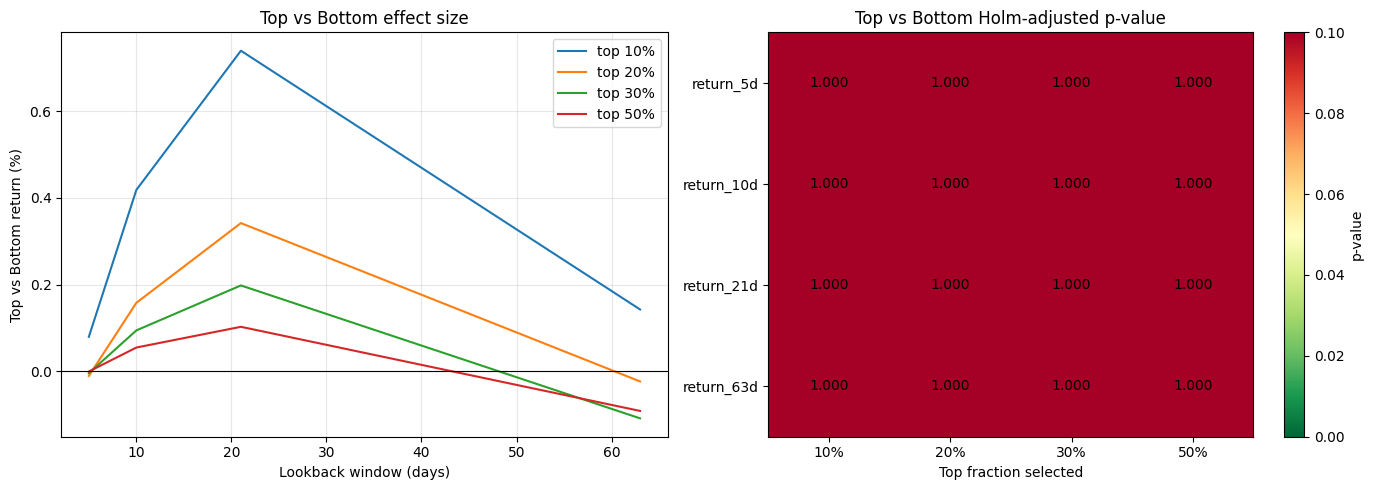

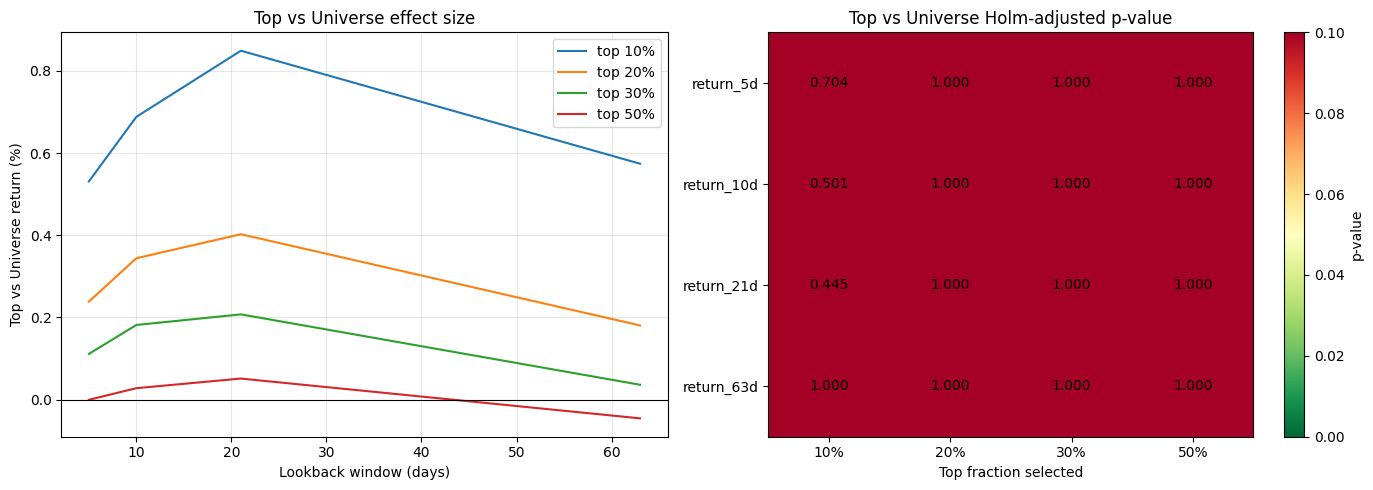

In [21]:
_ = plot_momentum_sweep(sweep_sp500)

The trend from previous methods follows over - the momentum approach seems to hold no significance on the S&P 500 when the approach is fixed in either top vs bottom and top vs universe approaches. Like above, we now test the adaptive walk-forward.

In [ ]:
mom_wf_sp500_folds, mom_wf_sp500_daily = walk_forward_momentum_rule(pooled_sp500_v2, train_size=504, test_size=63, horizon=21, embargo=21, expanding=True)

In [23]:
print(mom_wf_sp500_folds.to_string(index=False))
print("\nRules selected across S&P 500 folds:")
print(mom_wf_sp500_folds.groupby(['lookback', 'top_frac']).size().rename('n_folds').to_string())

print(f"\nMean out-of-sample top return:      {mom_wf_sp500_daily['top_return'].mean()*100:.4f}%")
print(f"Mean out-of-sample universe return: {mom_wf_sp500_daily['universe_return'].mean()*100:.4f}%")
print(f"Mean out-of-sample excess:          {mom_wf_sp500_daily['excess'].mean()*100:.4f}%")

t, p = hac_test(mom_wf_sp500_daily['excess'], horizon=21)
print(f"Out-of-sample excess vs 0 (HAC): t={t:.3f}, p={p:.4f}")
print(f"Fraction of test days where top beat universe: {(mom_wf_sp500_daily['excess'] > 0).mean():.2%}")
print(f"Fraction of folds where top beat universe: {(mom_wf_sp500_folds['excess'] > 0).mean():.2%}")

 fold train_start  train_end test_start   test_end   lookback  top_frac  train_mean_excess  train_t_hac  train_p_raw  n_test_days  top_return  universe_return    excess
    0  2021-11-24 2023-11-27 2023-12-28 2024-03-28 return_10d       0.1           0.003829     1.082700     0.279460           63    0.044689         0.024112  0.020576
    1  2021-11-24 2024-02-28 2024-04-01 2024-06-28 return_10d       0.1           0.004880     1.434160     0.152079           63    0.008974         0.013502 -0.004528
    2  2021-11-24 2024-05-29 2024-07-01 2024-09-27 return_10d       0.1           0.005180     1.675917     0.094251           63    0.013074         0.026511 -0.013437
    3  2021-11-24 2024-08-28 2024-09-30 2024-12-27 return_10d       0.1           0.002735     0.843563     0.399205           63    0.030472         0.005959  0.024513
    4  2021-11-24 2024-11-26 2024-12-30 2025-04-01 return_10d       0.1           0.004784     1.412646     0.158172           63   -0.041495        -0.026

Conversely to the results above, when performing the out of sample walk forward test, positive, statistically significant results were produced. The p-value is somewhat close to the significance level, and there is only ten folds here compared to the 30 we had previously. It is also key to note, the favoured approaches were 10d, 21d momentum with top 10% chosen, which is different to our findings on the smaller universe, but does suggest the momentum principle itself may hold, but not any specific parameter choice. It is also key to note survivorship bias when discussing the S&P 500 (that only well-perfoming companies remain in the S&P 500).

## PART 3


As found above, momentum is a useful signal for predicting positive performance of tickers compared to the market. We look for other relevent signals here, such as the PE-ratio (price-earnings, how much a share costs relative to the companies earnings per share) and ROE (return on equity).

In [24]:
fund = build_fundamental_features(tickers)
print(fund)
print(f"\nMissing data per column:")
print(fund.isna().sum())

          pe_ratio   pb_ratio      roe  debt_to_equity  profit_margin  \
ticker                                                                  
AAPL     35.538990  42.105976  1.48751          78.445        0.27619   
MSFT     27.423870   8.255015  0.34039          29.118        0.40305   
GOOGL    17.400200   6.817038  0.48676          18.859        0.54771   
AMZN     21.019323   5.103214  0.30558          45.617        0.17440   
NVDA     32.626340  26.400250  1.14288           6.555        0.62966   
META     21.470810   5.560379  0.29848          42.997        0.29835   
TSLA    324.305540  15.924073  0.04667          18.373        0.03671   
JPM      15.282348   2.681739  0.17789             NaN        0.34921   
JNJ      31.650059   7.741186  0.25742          57.709        0.21482   
XOM      20.647814   2.546607  0.12584          15.921        0.09072   
WMT      38.181160   8.894328  0.22314          70.378        0.03000   
PG       21.930616   6.336340  0.30290          64.

This is live data, hence as of the time of the original committing, we are not sure on the results. We create a composite signal, which encourages a low P-E ratio, and high ROE. This can be seen visibly in the plot below. Over time, we will iteratively apply the function 'forward_evaluation_tracking' which will see how our hypothesis works. Backtesting cannot be used as a result of limited data over time (~4 quarters of available data, not long enough for a robust solution).

In [25]:
forward_log_path = '../data/forward_test_log.csv'

if Path(forward_log_path).exists():
    log = pd.read_csv(forward_log_path)
    print(f"Loaded existing forward test started on "
        f"{log['start_date'].iloc[0]}")
else:
    log = start_forward_tracking(tickers, fund, output_path=forward_log_path)

Loaded existing forward test started on 2026-08-18


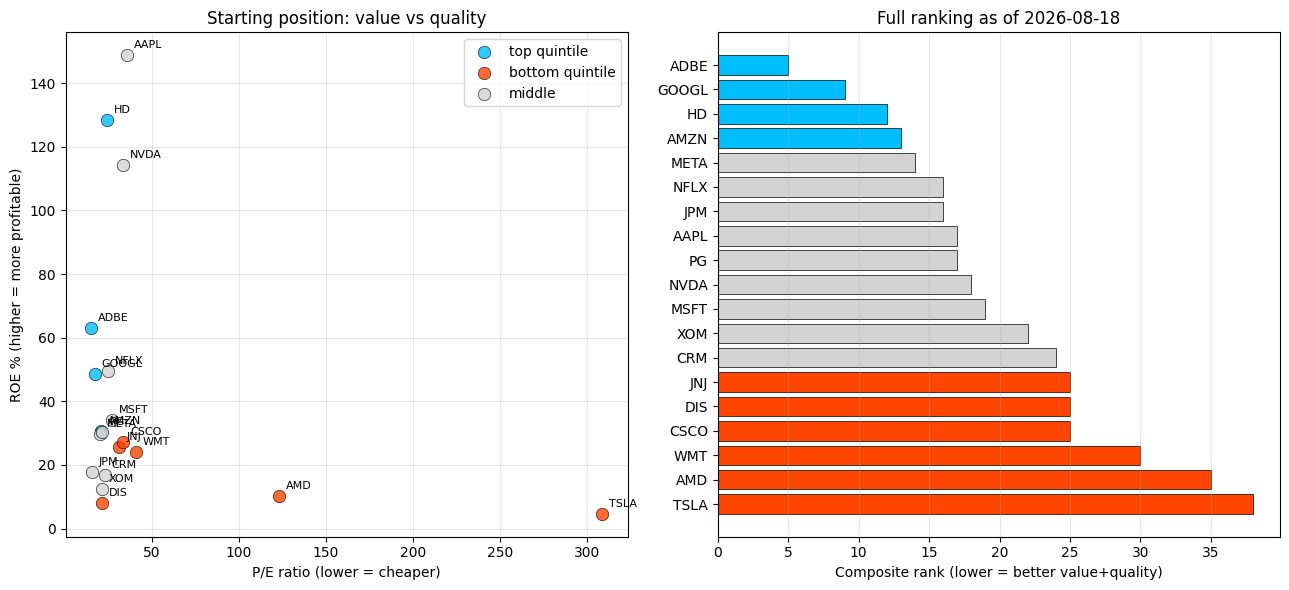


As time progresses we predict that blue (top quintile) should on average outperform orange/red (bottom quintile). Reapply function with forward_evaluation_tracking


In [26]:
plot_forward_test_setup(log)

In [27]:
forward_evaluation_tracking(log_path='../data/forward_test_log.csv')

Days since start date: 7
                     mean  count
group                           
bottom_quintile  0.002852      6
middle           0.009928      9
top_quintile     0.009619      4


,ticker,start_date,start_price,pe_ratio,roe,composite_rank,group,current_return
0,ADBE,2026-08-18,265.899994,15.211671,0.62954,5.0,top_quintile,0.030162
1,GOOGL,2026-08-18,343.244995,17.227410,0.48676,9.0,top_quintile,0.010823
2,HD,2026-08-18,339.750000,24.113556,1.28380,12.0,top_quintile,-0.005504
3,AMZN,2026-08-18,260.279999,20.926905,0.30558,13.0,top_quintile,0.002997
4,META,2026-08-18,544.369995,20.489275,0.29848,14.0,middle,0.047174
5,NFLX,2026-08-18,78.504997,24.683650,0.49541,16.0,middle,0.047449
6,JPM,2026-08-18,361.929993,15.503632,0.17789,16.0,middle,-0.014478
7,AAPL,2026-08-18,309.769989,35.567165,1.48751,17.0,middle,0.000420
8,PG,2026-08-18,143.610001,21.659878,0.30290,17.0,middle,0.012464
9,NVDA,2026-08-18,219.779800,33.651608,1.14288,18.0,middle,-0.030621
